# 1. Background

This notebook presents my approach to quantitative signal research, with an emphasis on commodity futures. The focus here is on a basic but practical framework for futures signal research. My background is primarily in energy markets, including Brent crude, WTI crude, Dubai crude, RBOB gasoline, and Singapore 92 motor gasoline. My experience across these markets has covered strategy research, execution, and discretionary trading.

Although my practical experience has been concentrated in energy futures, my research interests are broader and include systematic work across multiple asset classes.

Further details on my background and experiences can be found in my CV at https://elroy-goh.github.io/cv.

**Disclaimer**
-

The use of AI tools have been involved in writing up this notebook. Though to be clear, all core ideas and methodologies were from me, with knowledge synthesised from reading various books related to quantitative investing and from my college studies. ChatGPT/Claude were involved in coding and understanding some topics in more depth. Where AI tools were used, the generated outputs were checked through thoroughly.

In other words, all analytical frameworks and conclusions are my own. Also, I am proficient in Python programming, with more than 8 years of working experience using Python.

---

# 2. Introduction

This notebook develops a time-series signal research framework for commodity futures. This is unlike the Barra or Axioma-styled factor models where we perform a cross-sectional regression on each date (Similar styled workings as you would have read in Grinold and Kahn's (1999) foundational book on Active Portfolio Management, Qian et al (2007)  Quantitative Portfolio Management and many other equity research focused books).

Some pre-amble just so we are aligned on this: The reason we deviate from that is because cross sectionally, there isn't as many "assets" within the commodity space available to cleanly tease out factor returns. To make matters worse, the behavior and contract availability across commodities differ, i.e. energy futures behaves differently from agriculture futures and fixed income futures. It's (relatively) easy to trade along the curve of crude oil futures, as the front tenors (up to about 6mths out) are relatively well traded. In contrast, cocoa, coffee, soybean, etc, are generally liquid only at the front active contract. Anything beyond gets active only when the front month contract is approaching expiration and positions get rolled to the deferred month.

In this notebook, we shall only work on time-series models for each of the following "signals":
1) Carry
2) Long-term trend
3) Short-term mean reversion

We'll perform this analysis in the following order:
- Exploratory data analysis
- Signal definition and analysis
    - Signal validation: Calculate IC and it's statistics
    - Signal decay v horizon: Plot IC across multiple holding horizons
    - Study signal robustness: Study signal stability across regimes
- Backtest signals
- Orthogonalise signals to understand P&L contribution of a signal to existing pool of signals

Before we proceed, a quick note on the research direction.

## 2.1 Research Statement

We model the outright returns of the 2nd WTI futures contract (NB2) as the target variable. Carry, trend, and mean reversion are used as the candidate signals. The objective is to evaluate whether these signals contain predictive information for subsequent returns, how that predictive strength evolves across horizons, and whether each signal contributes distinct value within a broader research framework.

We perform our analysis and backtests on settlement prices. Any signals generated at time $T$, will be executed at time $T+1$

Prices, returns, etc are all calculated on raw absolute returns basis. The reason for this choice is that in energy markets, strategies are often built around spreads, e.g. Crack Spreads, Calendar Spreads, etc. Using percentage returns on prices that could be near or below 0 does not make economic sense. The interpretation and handling of returns at that point would then be a little problematic. To simplify things, using raw absolute returns would be more than sufficient.

---

# 3. Import libraries

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import spearmanr, pearsonr

# from utilities.database import get_structured_markings

from helper import (
    get_structured_markings, compute_terminal_change, _prepare_predictive_inputs, compute_predictive_corr,
    compute_predictive_corr_stats, compute_predictive_corr_series, compute_signal_turnover, compute_position_pnl,
    compute_position_turnover, compute_sharpe_raw, compute_sortino_raw, compute_drawdown_stats, classify_vol_regime,
    compute_top_drawdowns, assign_signal_buckets, compute_bucket_stats, classify_term_structure, summarise_regime,
    plot_signal_regime_summary, orthogonalise_signals_full_sample_sequential
)

---

# 4. Exploratory Data Analysis - Raw Data

Reason we're taking NB2 is because carry/roll yield is one of our "signals", so the expected move is on the deferred month contract. Here we'll perform some analysis on the data just to get a sense of how the return structure has been like.

In [2]:
# marks = get_structured_markings(
#     [
#         {'asset' : 'CL', 'weight' : 1, 'nearby' : 'NB2'}
#     ], rolling_type='LTD'
# )

# Load front-month marks and 2nd-month marks. This is a helper function reading csv files of data that has already been "rolled". (continuous contract)
# Roll methodology will be noted in the README.md file.
front_marks, marks = get_structured_markings()

# Existing "symbol" column has it's year truncated to only show the last digit. We'll have to transform it into it's full symbol, so that when we group
# them together, we do not group 2016 contract data with 2026
marks['year'] = marks.index.year
marks['year'] = marks.apply(lambda x: x.year if int(x.symbol[-1]) == x.year % 10 else x.year + 1, axis=1)
marks['full_contract_symbol'] = marks.apply(lambda x: x.symbol[:-1] + str(x.year%100), axis=1)

In [3]:
min_date, max_date = marks.index.min(), marks.index.max()
num_contracts = marks['full_contract_symbol'].nunique()

## 4.1 Price and Histogram of Returns

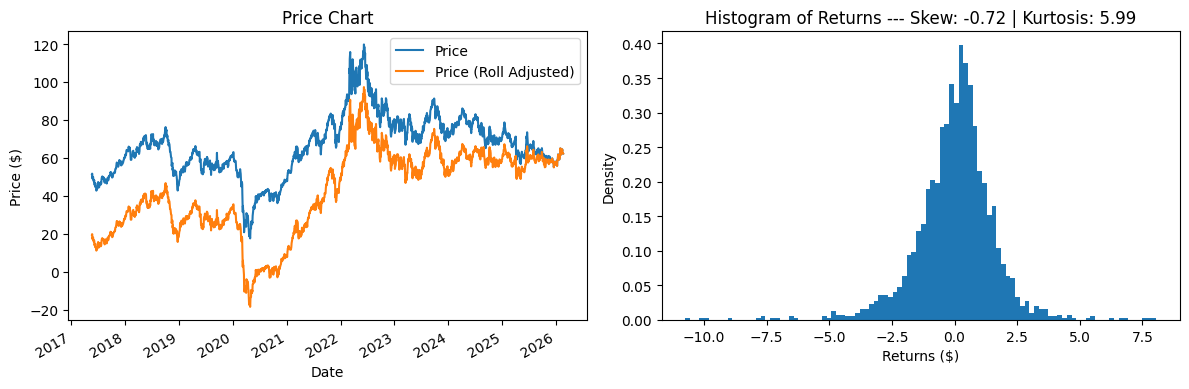

In [4]:
skew = marks['price_chg'].skew()
kurt = marks['price_chg'].kurt()

fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

# Price Chart
marks['price'].plot(label='Price', ax=axes[0])
marks['price_roll_adjusted'].plot(label='Price (Roll Adjusted)', ax=axes[0])

axes[0].set_title('Price Chart')
axes[0].set_ylabel('Price ($)')
axes[0].set_xlabel('Date')
axes[0].legend()

# Returns Histogram
axes[1].hist(marks['price_chg'], bins=100, density=True)

axes[1].set_title(f'Histogram of Returns --- Skew: {skew:.2f} | Kurtosis: {kurt:.2f}')
axes[1].set_ylabel('Density')
axes[1].set_xlabel('Returns ($)')

plt.tight_layout()
plt.show()

## 4.2 Returns by Pre & Post-Covid

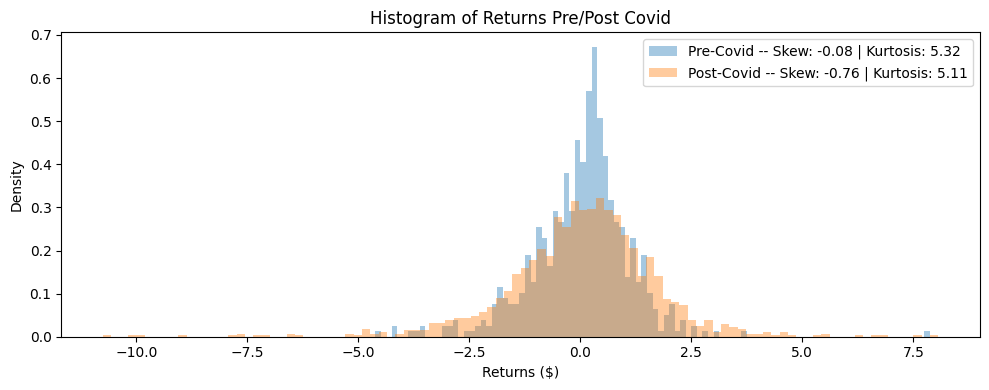

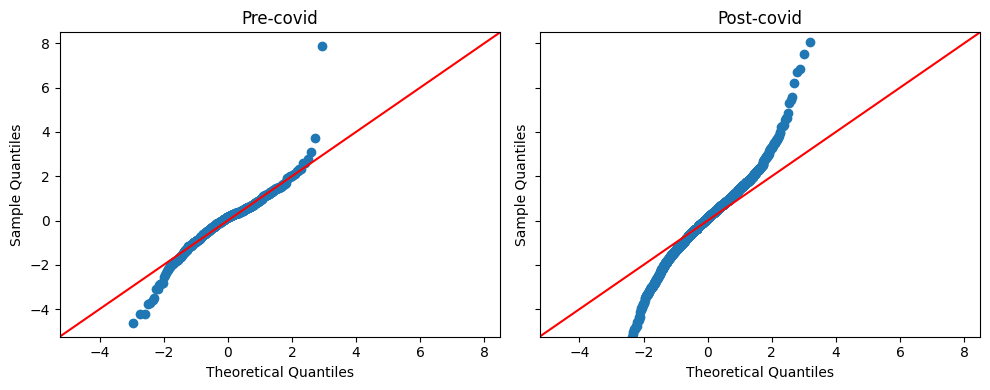

In [5]:
skew_pre  = marks[:'2019']['price_chg'].skew()
skew_post = marks['2020':]['price_chg'].skew()

kurt_pre  = marks[:'2019']['price_chg'].kurt()
kurt_post = marks['2020':]['price_chg'].kurt()

# Returns Histogram by Regime
plt.figure(figsize=(10, 4))
plt.hist(marks[:'2019']['price_chg'], bins=100, density=True, alpha=0.4, label=f'Pre-Covid -- Skew: {skew_pre:.2f} | Kurtosis: {kurt_pre:.2f}')
plt.hist(marks['2020':]['price_chg'], bins=100, density=True, alpha=0.4, label=f'Post-Covid -- Skew: {skew_post:.2f} | Kurtosis: {kurt_post:.2f}')

plt.title(f'Histogram of Returns Pre/Post Covid')
plt.ylabel('Density')
plt.xlabel('Returns ($)')
plt.legend()

plt.tight_layout()
plt.show()

# Q-Q Plot
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharex=True, sharey=True)
sm.qqplot(marks[:'2019']['price_chg'], line='45', ax=axes[0], label='Pre-Covid')
sm.qqplot(marks['2020':]['price_chg'], line='45', ax=axes[1], label='Post-Covid')

axes[0].set_title('Pre-covid')
axes[1].set_title('Post-covid')

plt.tight_layout()
plt.show()

## 4.3 ACF and PACF Plots
We'll try to identify if there are traits of AR/MA characteristics. If there are, we can also build an ARIMA model out of it.

### 4.3.1 ACF and PACF Plots of Daily Returns

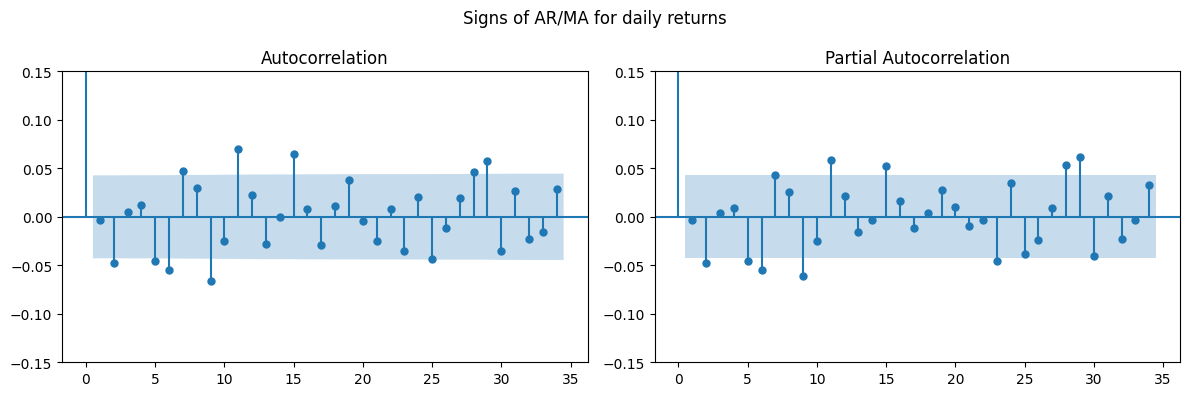

In [6]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))
plot_acf(marks['price_chg'], ax=axes[0])
plot_pacf(marks['price_chg'], ax=axes[1])

axes[0].set_ylim([-0.15, 0.15])
axes[1].set_ylim([-0.15, 0.15])

plt.suptitle('Signs of AR/MA for daily returns')
plt.tight_layout()
plt.show()

Returns on NB2 contract does not seem to display any distinct AR/MA traits. At least that does not seem to be the case. We shall group them by contract, just to have an understanding if contract month displays seasonal effects.

### 4.3.2 ACF and PACF Plots of Returns by Contract

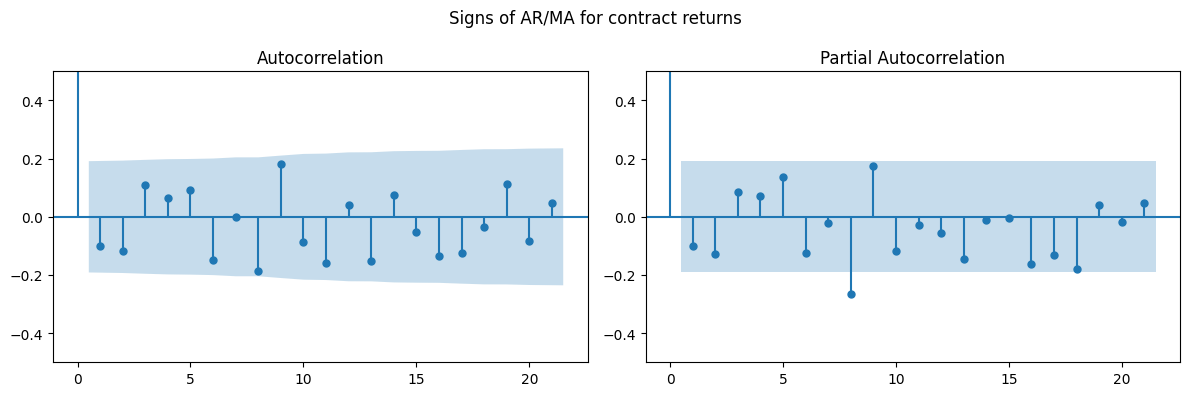

In [7]:
# Plot ACF and PACF
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))
plot_acf(marks.groupby('full_contract_symbol')['price_chg'].sum(), ax=axes[0])
plot_pacf(marks.groupby('full_contract_symbol')['price_chg'].sum(), ax=axes[1])

axes[0].set_ylim([-0.5, 0.5])
axes[1].set_ylim([-0.5, 0.5])

plt.suptitle('Signs of AR/MA for contract returns')
plt.tight_layout()
plt.show()

Expected to see spike in PACF at 12th lag, but does not seem to be significant either. Maybe, just maybe, this isn't the right way to represent or reflect such a characteristic.

## 4.4 Commentary on EDA

In [8]:
display(marks.describe(include=[np.float64]))
print(f'\nNumber of unique contracts: {num_contracts}')
print(f"\nData consists of daily settlement price, ranging from {min_date.date()} to {max_date.date()}")
print(f'\nNaN rows per column: \n')
display(marks.isna().sum().rename('NaN Count').to_frame())

,price,price_chg,price_roll_adjusted
count,2099.000000,2099.000000,2099.000000
mean,66.173516,0.020591,41.948580
std,16.044531,1.560932,22.376319
min,17.600000,-10.750000,-18.470000
25%,56.880000,-0.730000,25.610000
50%,66.140000,0.130000,43.220000
75%,76.065000,0.840000,59.610000
max,119.780000,8.060000,97.310000



Number of unique contracts: 105

Data consists of daily settlement price, ranging from 2017-05-22 to 2026-02-17

NaN rows per column: 



,NaN Count
price,0
price_chg,0
symbol,0
price_roll_adjusted,0
year,0
full_contract_symbol,0


Full range:
Returns of 2nd-month WTI contract is slightly left-skewed (skew: -0.72). However, it has significantly fatter tails with kurtosis of 5.99.

However, as market regimes might have changed pre and post-covid, we shall take a look at the return distributions separately.

Segregated view:
Skewness pre-covid seems to be near 0, whereas post-covid skewness was at -0.76. This however, does not constitute a very significant left skew. It is apparent, though, that the tails has gotten fatter post-covid as shown by the Q-Q Plot. This, however, does not corroborate with the kurtosis calculated in the chart titles. (See explanation below, it's mainly due to normalisation method)

Both ACF and PACF for daily and contract returns does not seem to be significant. That does not preclude the fact that seasonality effects may be present in structured spreads though.

### 4.4.1 Kurtosis Paradox Explained (Credits to Claude)

Kurtosis is a standardised moment: μ₄/σ⁴. Post-COVID realised volatility is materially higher, so even if absolute tail moves are larger, normalising by a larger σ⁴ can reduce or flatten the kurtosis metric. The Q-Q plots visualise absolute deviations from normality; kurtosis measures normalised ones. The table below compares absolute vs z-scored tail behaviour to make this explicit.

Additionally, the pre-COVID sample (2017–2019, ~2.5 years) includes the end-2018 crude selloff (WTI fell ~$40 in ~3 months) in a relatively low-vol environment, which produces a high normalised kurtosis. The post-COVID sample (2020–present) is longer and absorbs multiple stress events, so the tail events are large in absolute terms but not as extreme relative to the elevated σ.

In [9]:
pre  = marks[:'2019']['price_chg'].dropna()
post = marks['2020':]['price_chg'].dropna()

kurtosis_diagnosis = pd.DataFrame({
    'pre_covid': [
        pre.std(),
        pre.skew(),
        pre.kurt(),
        pre.quantile(0.01),
        pre.quantile(0.99),
        pre.quantile(0.01) / pre.std(),
        pre.quantile(0.99) / pre.std(),
    ],
    'post_covid': [
        post.std(),
        post.skew(),
        post.kurt(),
        post.quantile(0.01),
        post.quantile(0.99),
        post.quantile(0.01) / post.std(),
        post.quantile(0.99) / post.std(),
    ]
}, index=['std', 'skew', 'excess_kurtosis', 'p1_absolute', 'p99_absolute', 'p1_zscore', 'p99_zscore'])

display(kurtosis_diagnosis.round(3))

,pre_covid,post_covid
std,1.105,1.720
skew,-0.079,-0.762
excess_kurtosis,5.320,5.112
p1_absolute,-3.387,-4.933
p99_absolute,2.331,4.243
p1_zscore,-3.065,-2.867
p99_zscore,2.109,2.466


---

# 5. Signal

## 5.1 Signal Definition

**Carry**
- Carry or Roll Yield. Idea: during backwardation (positive spread), when the front-month contract expires, the deferred leg would roll up. Reason being that the contracts are intrinsically linked to the same underlying product.
$$F_0 = S_0 e^{(r+s-c)T}$$
- As expiration draws closer, T -> 0, prices would converge towards spot prices.
- That's the high level reasoning, however, in energy markets there are more nuances to it. There could be dislocation between spot and futures prices due to issues such as market stress, storage constraints, etc.
- We formulate the signal as: $$\frac{(F_{1,t} - F_{2,t})}{\sigma_{rolling}}$$

**Long-term trend**
- As with the paper by Jegadeesh and Titman (1993) on momentum, we posit that assets that have been trending up tend to keep outperforming.
- Though, to be clear, their paper was on cross-sectional basis.
- We ignore the recent returns in case of short-term reversals and formulate signals as: $$\frac{F_{2,t-skip} - F_{2,t-long lookback}}{\sigma_{rolling}}$$

**Short-term mean reversion**
- As with the saying, long-term trend, short term reversal. Short-term reversals are likely an artifact of overreaction in the market which then corrects itself shortly after --> Mean reversion
- We'll go with the 2MA crossover method.
- We formulate signals as: $$-\frac{SMA(5)_{F2} - SMA(20)_{F2}}{\sigma_{rolling}}$$
- The choice of 5 and 20 is entirely arbitrary. ML practitioners may treat this as a tunable parameter, discretionary traders swear by a fixed 14/21 rule, etc. I chose 5/20 just so I can keep the required data period under a month, with no particular reason.

In [10]:
# ================
# Signal functions
# ================

def signal_carry(F1: pd.Series, F2: pd.Series, vol_lookback: int = 60) -> pd.Series:
    """Carry: positive = backwardation = positive expected roll return."""
    
    signal = F1 - F2
    
    return signal / signal.rolling(window=vol_lookback, min_periods=vol_lookback).std().shift()


def signal_trend(F2: pd.Series, lookback: int = 252, skip: int = 21, vol_lookback: int = 60) -> pd.Series:
    """12-1 month trend: formation return from t-lookback to t-skip."""
    
    signal = F2.shift(skip) - F2.shift(lookback)
    
    return signal / signal.rolling(window=vol_lookback, min_periods=vol_lookback).std().shift()


def signal_mr(F2: pd.Series, st_window: int = 5, lt_window: int = 20, vol_lookback: int = 60) -> pd.Series:
    """Short-term mean reversion via a moving-average crossover."""
    
    signal = F2.rolling(window=st_window, min_periods=st_window).mean() - F2.rolling(window=lt_window, min_periods=lt_window).mean()
    
    return -signal / signal.rolling(window=vol_lookback, min_periods=vol_lookback).std().shift()

def compute_forward_change(price_chg: pd.Series, horizon: int) -> pd.Series:
    """Compute the forward cumulative dollar change from t+1 to t+horizon."""
    return price_chg.rolling(window=horizon, min_periods=horizon).sum().shift(-horizon)

In [11]:
signals = {
    
    # We use price here, because backwardation/contango is state dependent, can't use roll-adjusted prices.
    'carry' : signal_carry(front_marks['price'], marks['price']),

    # Roll adjusted price contains all cumulative sum of returns, which is appropriate for trend and mr calculations.
    'trend' : signal_trend(marks['price_roll_adjusted'], lookback=252, skip=21),
    'mean_reversion' : signal_mr(marks['price_roll_adjusted']),
    
}

signals_df = pd.DataFrame(signals).dropna()
signals_df.head()

,carry,trend,mean_reversion
ts_ref,,,
2018-09-06,0.405496,9.751891,-0.797108
2018-09-07,0.326463,9.867621,-0.564318
2018-09-10,0.213163,9.016418,-0.347957
2018-09-11,0.345100,9.329592,-0.245259
2018-09-12,0.346672,9.432413,-0.338540


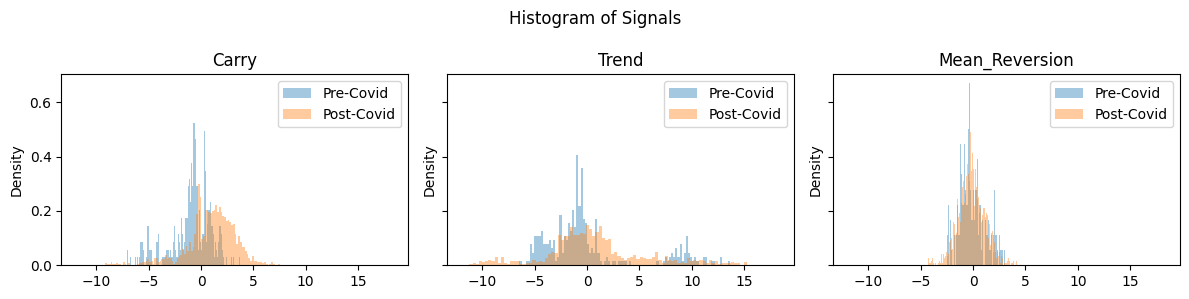

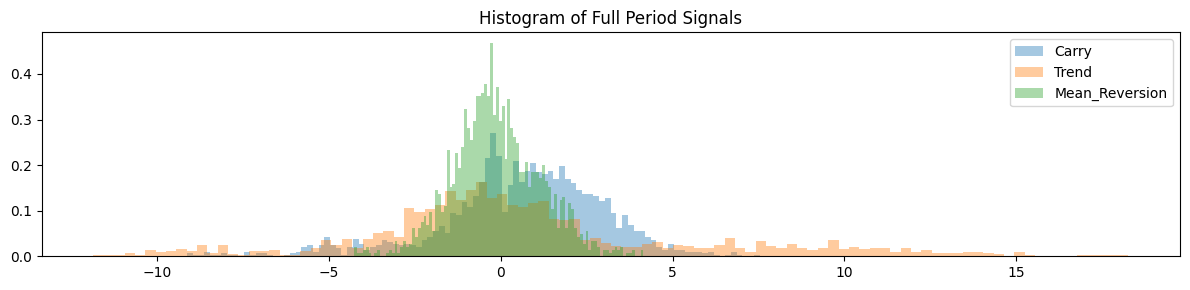

In [12]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 3), sharex=True, sharey=True)
for i, signal in enumerate(signals_df.columns):
    axes[i].hist(signals_df[:'2019'][signal], bins=100, density=True, alpha=0.4, label='Pre-Covid')
    axes[i].hist(signals_df['2020':][signal], bins=100, density=True, alpha=0.4, label='Post-Covid')
    axes[i].set_title(signal.title())
    axes[i].legend()
    axes[i].set_ylabel('Density')

plt.suptitle('Histogram of Signals')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
for signal in signals_df.columns:
    plt.hist(signals_df[signal], bins=100, density=True, alpha=0.4, label=signal.title())

plt.title('Histogram of Full Period Signals')
plt.legend()
plt.tight_layout()
plt.show()

The purpose of this plot is to understand if there are any signal drifts pre to post covid. Carry seems to have turned more positive post-covid. Which is not unexpected. At least for the earlier years, it makes sense for the energy market to be in backwardation (+ve carry/spread). The rest seems more or less align

## 5.2 Signal Statistics


For a single-instrument study, we would want to know whether the signal is persistent, whether it overlaps materially with the other signals, and whether stronger signal buckets are followed by larger subsequent dollar moves over the same horizon used in the backtest. We study these in the following sections.

Signal persistence gives a clue towards turnover and cost drag, or even an insight into whether it is just a long single stale exposure instead of multiple repeatable opportunities.

Being able to identify how much a signal overlaps with other signals will allow us to understand the contribution of this signal. If we treat highly correlated signals as independent ones, we would end up being overweight on the same exposure.

Bucket monotonicity asks whether stronger signal realizations line up with stronger subsequent moves in the expected direction.


In [13]:
signal_stats = pd.DataFrame(
    {
        'n_obs'                   : signals_df.count(),
        'mean'                    : signals_df.mean(),
        'std'                     : signals_df.std(),
        'skew'                    : signals_df.skew(),
        'kurtosis'                : signals_df.kurt(),
        'autocorr_1d'             : signals_df.apply(lambda x: x.autocorr(lag=1)),
        'autocorr_5d'             : signals_df.apply(lambda x: x.autocorr(lag=5)),
        'autocorr_21d'            : signals_df.apply(lambda x: x.autocorr(lag=21)),
        'sign_change_rate'        : signals_df.apply(lambda x: np.sign(x).diff().ne(0).mean()),
        'avg_abs_position_change' : signals_df.apply(compute_signal_turnover),
    }
).round(3)

display(signal_stats)
display(signals_df.corr().round(3))

,n_obs,mean,std,skew,kurtosis,autocorr_1d,autocorr_5d,autocorr_21d,sign_change_rate,avg_abs_position_change
carry,1726,0.590,2.425,-0.811,1.510,0.978,0.911,0.675,0.037,0.065
trend,1726,0.759,4.892,0.669,0.827,0.995,0.971,0.863,0.036,0.071
mean_reversion,1726,-0.126,1.277,0.125,0.365,0.977,0.650,0.027,0.060,0.119


,carry,trend,mean_reversion
carry,1.000,0.417,-0.237
trend,0.417,1.000,0.041
mean_reversion,-0.237,0.041,1.000


From the autocorrelation numbers, we can see that carry and trend are both very persistent. Both retained substantial 21-day correlation, though it is not unexpected, since the term structure (carry) is intricately linked to fundamentals and the S&D situations could often persist for long periods of time. Trend is calculated with a rather long lookback period, and therefore the signal is also expected to move more slowly, and has higher autocorrelation. Mean reversion is much less persistent by the 21-day horizon and has the highest sign-change rate and average position change, so it is in a sense the most expensive of the three to trade.

The correlation matrix is also useful. Carry and trend have a moderate positive correlation of 0.42, which suggests some shared directional structure, but neither is close enough to be treated as a duplicate signal. Mean reversion is weakly related to the other two, especially to trend, which is encouraging from a diversification perspective.

## 5.3 Preparation of Backtest DataFrame

Predictive tests are kept in raw absolute (dollar) changes so that IC, bucket monotonicity, and directional checks stay aligned to the same unit of analysis. The predictive horizon is set to `2D`, consistent with a signal observed at $T$, executed at $T+1$. In other words, the above are evaluated against the price change in WTI from T+1 to T+2.

This makes sense in the context of this notebook because we lag our trade by a day. However, when working on this as a live trading strategy, we would seek to use intraday data and assume we could trade after a short delay after the settlement price prints.

In our backtest, we assume if the signal does not change signs, the position persists and carries over to the next period. Alternatives to this could be vol scaling, where we scale in and out of a position depending on realised/expected volatility or we could also increase/decrease holdings at discrete points of the signal, e.g. 1/2/3 z-score from 0.

We additionally assume that the one-way cost per futures traded is $0.02. This is a fair cost, seeing that we could enter and exit positions via TAS (Trade at Settlement -- 0 slippage). The 2c should be sufficient to cover exchange cost and other fees.

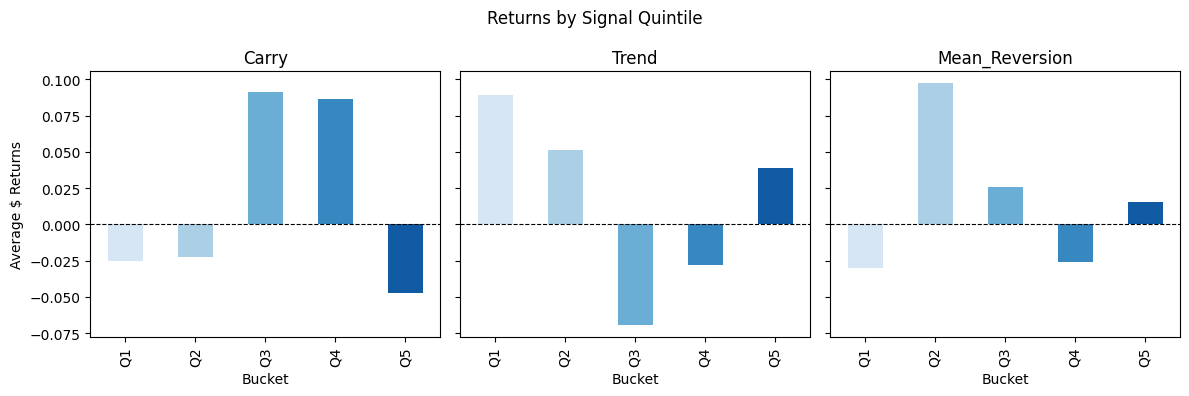


=====
Carry
=====


,count,mean,median,hit_rate
bucket,,,,
Q1,345,-0.025,0.130,0.464
Q2,345,-0.023,0.050,0.455
Q3,344,0.091,0.215,0.570
Q4,345,0.087,0.090,0.528
Q5,345,-0.047,0.030,0.510



=====
Trend
=====


,count,mean,median,hit_rate
bucket,,,,
Q1,345,0.089,0.16,0.449
Q2,345,0.051,0.19,0.461
Q3,344,-0.069,0.03,0.488
Q4,345,-0.028,0.02,0.504
Q5,345,0.039,0.23,0.562



Mean_Reversion


,count,mean,median,hit_rate
bucket,,,,
Q1,345,-0.030,0.07,0.470
Q2,345,0.097,0.17,0.435
Q3,344,0.026,0.04,0.468
Q4,345,-0.026,0.14,0.533
Q5,345,0.016,0.15,0.528


,top_minus_bottom_spread
carry,-0.022
trend,-0.050
mean_reversion,0.046


In [14]:
HORIZON_DAYS                  = 2
IC_HORIZONS                   = range(1, 11)
ROLLING_IC_WINDOW             = 126
TERM_STRUCTURE_FLAT_THRESHOLD = 0.10 # We classify the term-structure regime to be "flat" if it is within +/- $0.10
ONE_WAY_COST_PER_CONTRACT     = 0.02
PERIODS_PER_YEAR              = 252

backtest_df = pd.concat([
    marks,
    front_marks['price'].rename('front_price'),
    signals_df,
], axis=1).dropna().copy()

# Difference between forward change and terminal change is that:
# Forward change is a cumulative sum of returns over the next n days
# On the other hand, terminal change is the returns on the n'th day forward. (Just 1 day)
backtest_df['term_structure_spread'] = backtest_df['front_price'] - backtest_df['price']
backtest_df[f'forward_change_{HORIZON_DAYS}d'] = compute_forward_change(backtest_df['price_chg'], HORIZON_DAYS)
backtest_df[f'terminal_change_{HORIZON_DAYS}d'] = compute_terminal_change(backtest_df['price_chg'], HORIZON_DAYS)

for signal in signals_df.columns:
    backtest_df[f'{signal}_bucket'] = assign_signal_buckets(backtest_df[signal], n_buckets=5)

backtest_df['term_structure_regime'] = classify_term_structure(
    backtest_df['term_structure_spread'],
    flat_threshold=TERM_STRUCTURE_FLAT_THRESHOLD,
)
backtest_df.loc[backtest_df[:'2019'].index, 'pre_post_covid'] = 'pre'
backtest_df.loc[backtest_df['2020':].index, 'pre_post_covid'] = 'post'

bucket_tables = {}
bucket_spreads = {}
fig, axes = plt.subplots(ncols=3, figsize=(12, 4), sharey=True)

for i, signal in enumerate(signals_df.columns):
    bucket_table, top_minus_bottom = compute_bucket_stats(
        backtest_df[signal],
        backtest_df[f'terminal_change_{HORIZON_DAYS}d'], # Terminal 
        n_buckets=5,
    )
    bucket_tables[signal] = bucket_table
    bucket_spreads[signal] = top_minus_bottom
    bucket_table['mean'].plot(kind='bar', ax=axes[i], color=sns.color_palette('Blues', n_colors=bucket_table.shape[0]))
    axes[i].set_title(f'{signal.title()}')
    axes[i].set_ylabel('Average $ Returns')
    axes[i].set_xlabel('Bucket')
    axes[i].axhline(0, c='black', lw=0.8, ls='--')

plt.suptitle(f'Returns by Signal Quintile')
plt.tight_layout()
plt.show()

for signal, bucket_table in bucket_tables.items():
    print('\n'+'='*len(signal))
    print(signal.title())
    print('='*len(signal))
    display(bucket_table.round(3))

display(pd.Series(bucket_spreads, name='top_minus_bottom_spread').to_frame().round(3))


For bucket monotonicity to be strong, the expectations would be for Q1 returns to be negative (assuming most signals in Q1 is negative) and progressively increase to positive by Q5.

Bucket monotonicity is weak overall. Carry and trend are not monotonic and both have negative top-minus-bottom spreads (-0.022 and -0.05 respectively), which means stronger signal magnitude is not translating cleanly into stronger subsequent returns. Mean reversion has the best top-minus-bottom spread (0.046), but the bucket profile is still noisy rather than smoothly ordered. 

## 5.4 Information Coefficient and Decay Profile

The point of this section is two-fold. I want:

1) Decay profile for the signal across holding horizons. 
2) Separate cumulative IC from the marginal daily move, because cumulative forward windows overlap by construction and can therefore look artificially smooth.

Spearman is the headline measure here because the bucket test is fundamentally monotonic in spirit, while Pearson is retained as a sensitivity check.

In [15]:
ic_summary = []
for signal in signals_df.columns:
    for horizon in IC_HORIZONS:
        cumulative_change   = compute_forward_change(backtest_df['price_chg'], horizon)
        terminal_change     = compute_terminal_change(backtest_df['price_chg'], horizon)
        spearman_cumulative = compute_predictive_corr(backtest_df[signal], cumulative_change, method='spearman')
        pearson_cumulative  = compute_predictive_corr(backtest_df[signal], cumulative_change, method='pearson')
        spearman_terminal   = compute_predictive_corr(backtest_df[signal], terminal_change, method='spearman')
        pearson_terminal    = compute_predictive_corr(backtest_df[signal], terminal_change, method='pearson')

        non_overlapping = pd.concat([
            backtest_df[signal].rename('signal'),
            cumulative_change.rename('forward_change'),
        ], axis=1).dropna().iloc[::horizon]
        non_overlapping_spearman = compute_predictive_corr(
            non_overlapping['signal'],
            non_overlapping['forward_change'],
            method='spearman',
        )
        non_overlapping_pearson = compute_predictive_corr(
            non_overlapping['signal'],
            non_overlapping['forward_change'],
            method='pearson',
        )

        ic_summary.append({
            'signal'                              : signal,
            'horizon'                             : horizon,
            'spearman_cumulative'                 : spearman_cumulative,
            'pearson_cumulative'                  : pearson_cumulative,
            'spearman_terminal'                   : spearman_terminal,
            'pearson_terminal'                    : pearson_terminal,
            'spearman_cumulative_non_overlapping' : non_overlapping_spearman,
            'pearson_cumulative_non_overlapping'  : non_overlapping_pearson,
        })

ic_df = pd.DataFrame(ic_summary)
ic_df.head()


,signal,horizon,spearman_cumulative,pearson_cumulative,spearman_terminal,pearson_terminal,spearman_cumulative_non_overlapping,pearson_cumulative_non_overlapping
0,carry,1,0.003140,0.000197,0.003140,0.000197,0.003140,0.000197
1,carry,2,0.009204,-0.005146,-0.004593,-0.007524,0.005245,-0.004034
2,carry,3,-0.004434,-0.010417,-0.005238,-0.010484,-0.020123,-0.012508
3,carry,4,-0.011608,-0.014405,-0.001102,-0.010682,-0.012101,-0.016999
4,carry,5,-0.015239,-0.020304,-0.001099,-0.016310,-0.009260,-0.010497


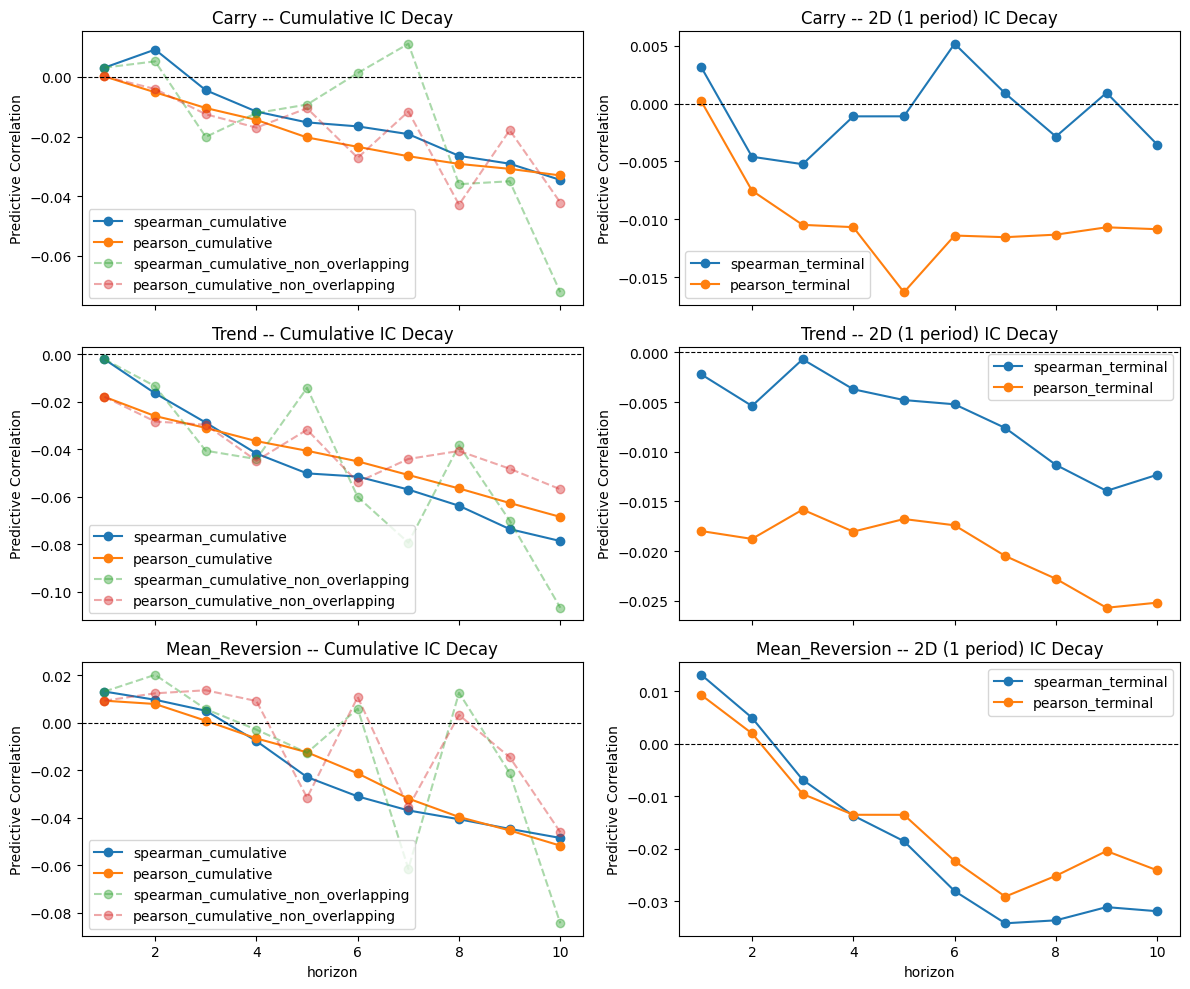

,signal,spearman_cumulative,pearson_cumulative,spearman_terminal,pearson_terminal,spearman_cumulative_non_overlapping,pearson_cumulative_non_overlapping
1,carry,0.009,-0.005,-0.005,-0.008,0.005,-0.004
11,trend,-0.017,-0.026,-0.005,-0.019,-0.014,-0.028
21,mean_reversion,0.010,0.008,0.005,0.002,0.020,0.012


In [16]:
fig, axes = plt.subplots(nrows=len(signals_df.columns), ncols=2, figsize=(12, 10), sharex=True)
if len(signals_df.columns) == 1:
    axes = np.array([axes])

for row_idx, signal in enumerate(signals_df.columns):
    signal_ic = ic_df[ic_df['signal'] == signal].set_index('horizon')

    signal_ic[['spearman_cumulative', 'pearson_cumulative']].plot(
        ax=axes[row_idx, 0], marker='o'
    )
    signal_ic[['spearman_cumulative_non_overlapping', 'pearson_cumulative_non_overlapping']].plot(
        ax=axes[row_idx, 0], marker='o', alpha=0.4, ls='--'
    )
    signal_ic[['spearman_terminal', 'pearson_terminal']].plot(ax=axes[row_idx, 1], marker='o')

    axes[row_idx, 0].set_title(f'{signal.title()} -- Cumulative IC Decay')
    axes[row_idx, 1].set_title(f'{signal.title()} -- 2D (1 period) IC Decay')
    axes[row_idx, 0].set_ylabel('Predictive Correlation')
    axes[row_idx, 1].set_ylabel('Predictive Correlation')
    axes[row_idx, 0].axhline(0, c='black', lw=0.8, ls='--')
    axes[row_idx, 1].axhline(0, c='black', lw=0.8, ls='--')

plt.tight_layout()
plt.show()

display(
    ic_df[ic_df['horizon'] == HORIZON_DAYS][[
        'signal',
        'spearman_cumulative',
        'pearson_cumulative',
        'spearman_terminal',
        'pearson_terminal',
        'spearman_cumulative_non_overlapping',
        'pearson_cumulative_non_overlapping',
    ]].round(3)
)


On aggregate, information coefficients are small across the board. As recommended in Grinold and Kahn (1999), an 
IC of 0.05 is considered good and 0.10 exceptional, so these results remain weak by that standard. The IC at horizon 1 - which is shown mainly as a same-day reference case rather than the tradable implementation in this notebook - also does not show much potential.

Trend Spearman IC is negative across horizons, which suggests that the way it is currently constructed moves against the stated hypothesis. Carry is mixed but remains close to zero, so it is not providing convincing predictive evidence either.

We shall dissect the signals a little, across different regimes to understand if the signal may perform better under different circumstances.

### 5.4.1 IC Stability

We study the stability of IC across a narrow range of parameters. The goal here is not to optimise our results, but instead, to check if the signs and magnitude of predictions are stable in the neighborhood of defined settings.

> **Note:** I would often run a check of IC on aggregate and against different regimes first, to study IC using the current parameters before looking into the IC stability. If the results does not produce anything meaningful, I would close the research as there is unlikely any more value to extract and any backtest results would be based off spurious relationship. However, I would not be performing that here as it might end up bloating this entire notebook and deviating from the original purpose.

*The cumulative-horizon IC decay is shown mainly descriptively. If one were to attach t-stats to those cumulative windows, overlap would need to be handled because the forward windows share observations. That concern does not apply in the same way to the single-day realised-change tests used elsewhere in the notebook.*

,signal_family,param_x,param_y,spearman_ic,ic_t_stat,n_obs,sharpe
0,carry,50,vol_lookback,-0.004,-0.178,1724,0.311
1,carry,55,vol_lookback,-0.004,-0.197,1724,0.311
2,carry,60,vol_lookback,-0.005,-0.221,1724,0.311
3,carry,65,vol_lookback,-0.004,-0.212,1719,0.316
4,carry,70,vol_lookback,-0.003,-0.161,1714,0.325
5,trend,245,18,-0.006,-0.267,1724,-0.298
6,trend,245,21,-0.008,-0.338,1724,-0.422
7,trend,245,24,-0.006,-0.239,1724,-0.413
8,trend,252,18,-0.004,-0.184,1724,-0.150
9,trend,252,21,-0.005,-0.236,1724,-0.198


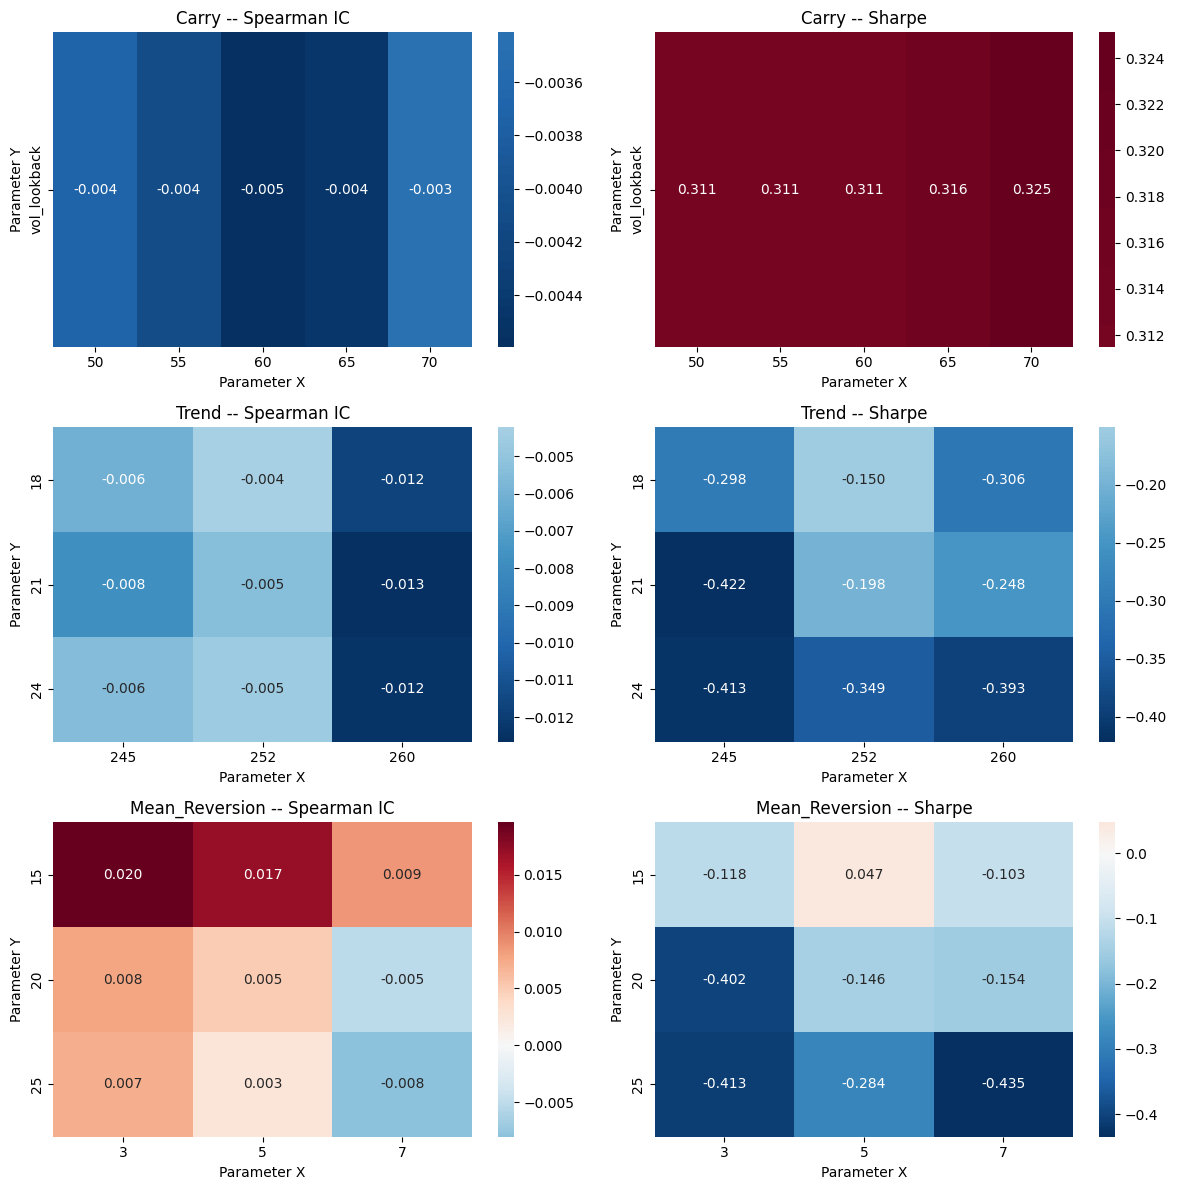

In [17]:
parameter_results = []

def append_parameter_result(signal_family: str, param_x, param_y, signal: pd.Series) -> None:
    aligned = pd.concat([
        signal.rename('signal'),
        backtest_df[f'terminal_change_{HORIZON_DAYS}d'],
    ], axis=1).dropna()
    spearman_stats = compute_predictive_corr_stats(
        aligned['signal'],
        aligned[f'terminal_change_{HORIZON_DAYS}d'],
        method='spearman',
    )
    net_pnl = compute_position_pnl(
        aligned['signal'],
        aligned[f'terminal_change_{HORIZON_DAYS}d'],
        one_way_cost=ONE_WAY_COST_PER_CONTRACT,
    )
    parameter_results.append({
        'signal_family': signal_family,
        'param_x': param_x,
        'param_y': param_y,
        'spearman_ic': spearman_stats['corr'],
        'ic_t_stat': spearman_stats['t_stat'],
        'n_obs': spearman_stats['n_obs'],
        'sharpe': compute_sharpe_raw(net_pnl, periods_per_year=PERIODS_PER_YEAR),
    })

carry_grid = [50, 55, 60, 65, 70]
for vol_lookback in carry_grid:
    signal = signal_carry(front_marks['price'], marks['price'], vol_lookback=vol_lookback)
    append_parameter_result('carry', vol_lookback, 'vol_lookback', signal)

trend_lookbacks = [245, 252, 260]
trend_skips = [18, 21, 24]
for lookback in trend_lookbacks:
    for skip in trend_skips:
        if skip >= lookback:
            continue
        signal = signal_trend(marks['price_roll_adjusted'], lookback=lookback, skip=skip)
        append_parameter_result('trend', lookback, skip, signal)

mr_short_windows = [3, 5, 7]
mr_long_windows = [15, 20, 25]
for st_window in mr_short_windows:
    for lt_window in mr_long_windows:
        if st_window >= lt_window:
            continue
        signal = signal_mr(marks['price_roll_adjusted'], st_window=st_window, lt_window=lt_window)
        append_parameter_result('mean_reversion', st_window, lt_window, signal)

parameter_df = pd.DataFrame(parameter_results)
display(parameter_df.round(3))

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
for row_idx, signal_family in enumerate(['carry', 'trend', 'mean_reversion']):
    subset = parameter_df[parameter_df['signal_family'] == signal_family]
    metric_tables = {
        'Spearman IC': subset.pivot(index='param_y', columns='param_x', values='spearman_ic'),
        'Sharpe': subset.pivot(index='param_y', columns='param_x', values='sharpe'),
    }
    for col_idx, (title, metric_table) in enumerate(metric_tables.items()):
        sns.heatmap(metric_table, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[row_idx, col_idx])
        axes[row_idx, col_idx].set_title(f'{signal_family.title()} -- {title}')
        axes[row_idx, col_idx].set_xlabel('Parameter X')
        axes[row_idx, col_idx].set_ylabel('Parameter Y')

plt.tight_layout()
plt.show()


## 5.5 IC By Regimes

### 5.5.1 Across Contango / Flat / Backwardation Regimes

Term structure for energy futures is arguably one of the most economically relevant regime split. Something I learned from my past experience is that when the term structure flips from contango to backwardation or vice versa, that flip can be very abrupt. Therefore, being near a spread of 0 could potentially be informative of subsequent move. However, we shall not study this in depth in this notebook as the main purpose of this isn't to be exhaustive in our search for potential signals, but rather, display research competencies and methodologies.

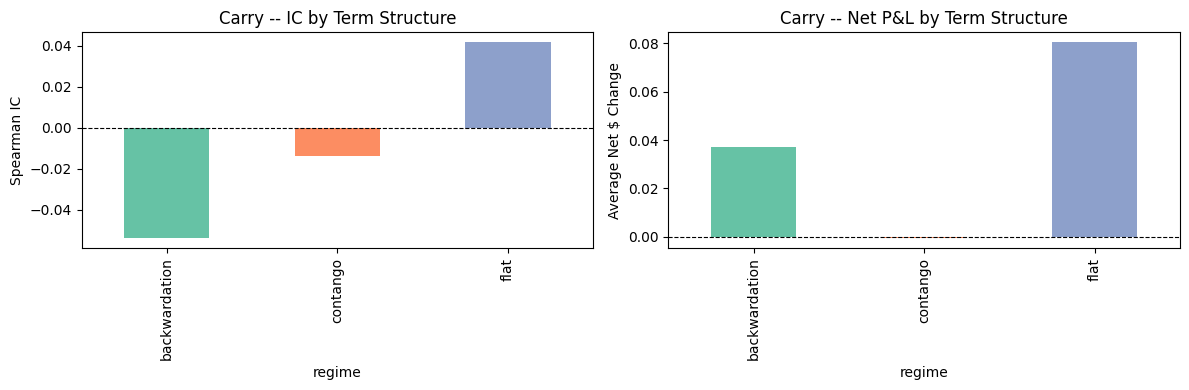

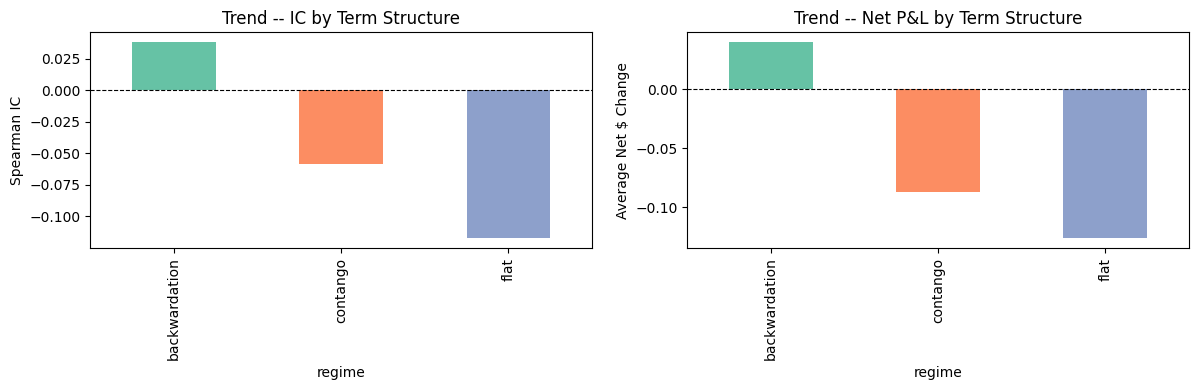

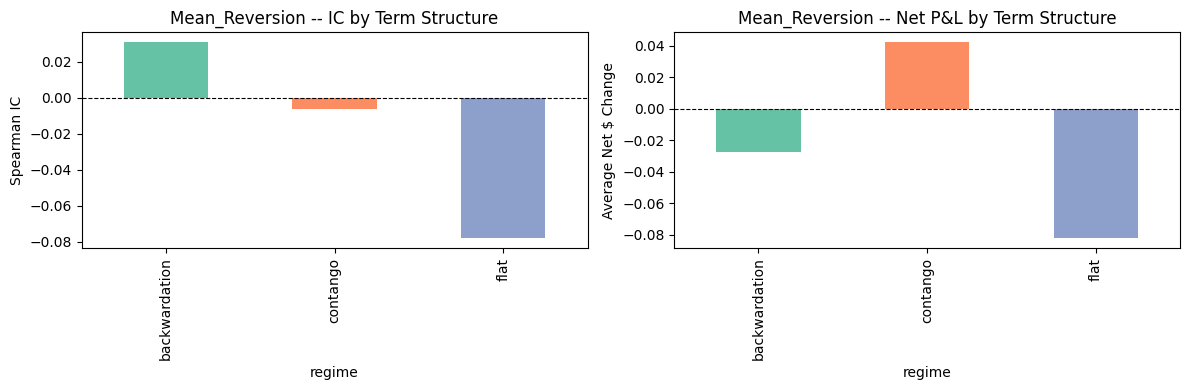

In [19]:
for signal in signals_df.columns:
    backtest_df[f'{signal}_net_pnl'] = compute_position_pnl(
        backtest_df[signal],
        backtest_df[f'terminal_change_{HORIZON_DAYS}d'],
        one_way_cost=ONE_WAY_COST_PER_CONTRACT,
    )

term_structure_regime_summaries = {}
for signal in signals_df.columns:
    summary_df = summarise_regime(
        backtest_df[signal],
        backtest_df[f'terminal_change_{HORIZON_DAYS}d'],
        backtest_df[f'{signal}_net_pnl'],
        backtest_df['term_structure_regime'],
    )
    term_structure_regime_summaries[signal] = summary_df
    plot_signal_regime_summary(summary_df, signal_name=signal, regime_name='Term Structure')


In [20]:
for signal, summary_df in term_structure_regime_summaries.items():
    print('\n' + '='*len(signal))
    print(signal)
    print('='*len(signal))
    display(summary_df.round(3))


=====
carry
=====


,n_obs,spearman_ic,pearson_ic,ic_t_stat,avg_net_pnl,hit_rate,sharpe
regime,,,,,,,
backwardation,975,-0.054,-0.032,-1.876,0.037,0.537,0.325
contango,496,-0.014,-0.040,-0.344,-0.000,0.472,-0.005
flat,253,0.042,0.087,0.773,0.080,0.447,0.922



=====
trend
=====


,n_obs,spearman_ic,pearson_ic,ic_t_stat,avg_net_pnl,hit_rate,sharpe
regime,,,,,,,
backwardation,975,0.038,0.007,1.327,0.040,0.522,0.349
contango,496,-0.059,-0.099,-1.371,-0.087,0.464,-0.932
flat,253,-0.117,-0.106,-2.316,-0.126,0.435,-1.430



mean_reversion


,n_obs,spearman_ic,pearson_ic,ic_t_stat,avg_net_pnl,hit_rate,sharpe
regime,,,,,,,
backwardation,975,0.031,0.044,1.063,-0.027,0.476,-0.238
contango,496,-0.007,-0.046,-0.136,0.042,0.520,0.454
flat,253,-0.078,-0.075,-1.333,-0.082,0.451,-0.931


Conditioning on term structure, carry's interpretation makes it somewhat different from others, in the sense that a positive carry is essentially backwardation (term structure) and negative reflects contango. So the signal and the regime is essentially one and the same. 

Carry does not behave as originally hypothesised. If the construction were working cleanly, I would expect IC to be positive. Instead, IC is negative in backwardation and near flat in contango, even though P&L is positive in backwardation and strongest when the curve is flat. I would therefore not read this as a clean ordinal relationship, nor as an especially reliable standalone P&L.

Trend is only mildly constructive in backwardation and clearly poor in contango. Mean reversion is weak overall.

So the main takeaway from this section is not that any signal is strong, but that market structure does appear to matter for how weak signals behave.

### 5.5.2 Across Volatility Regimes


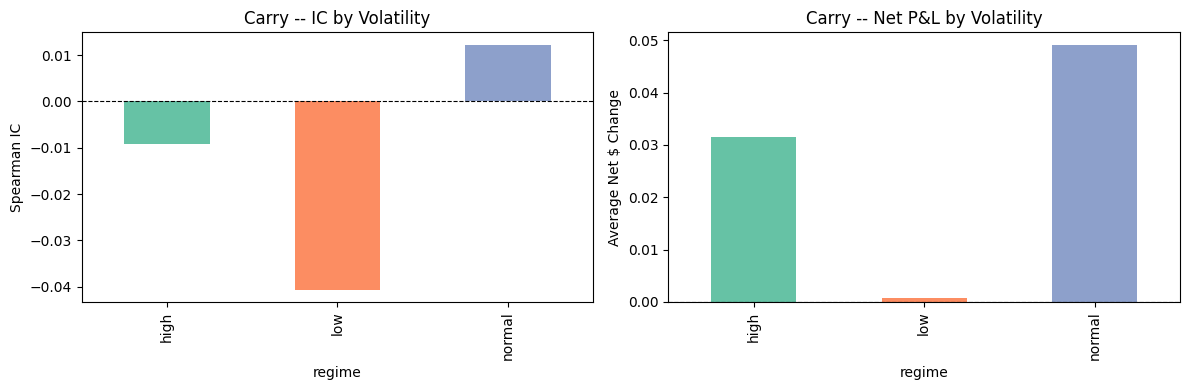

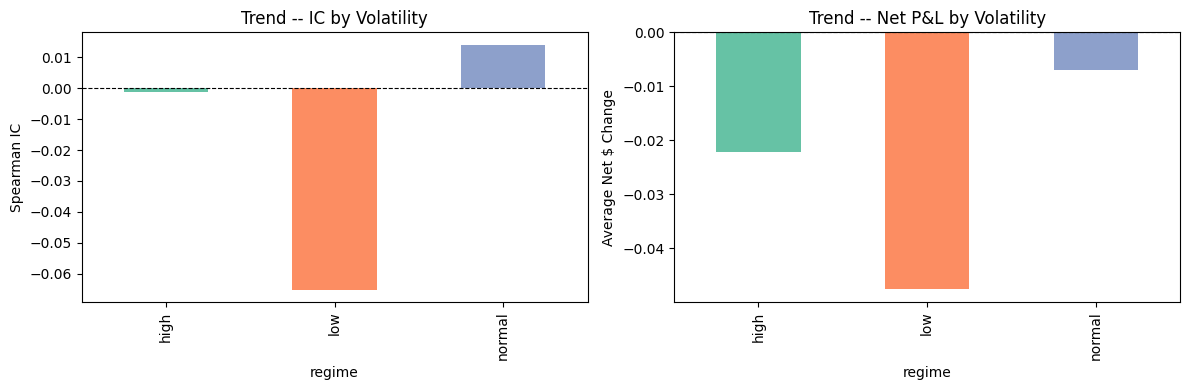

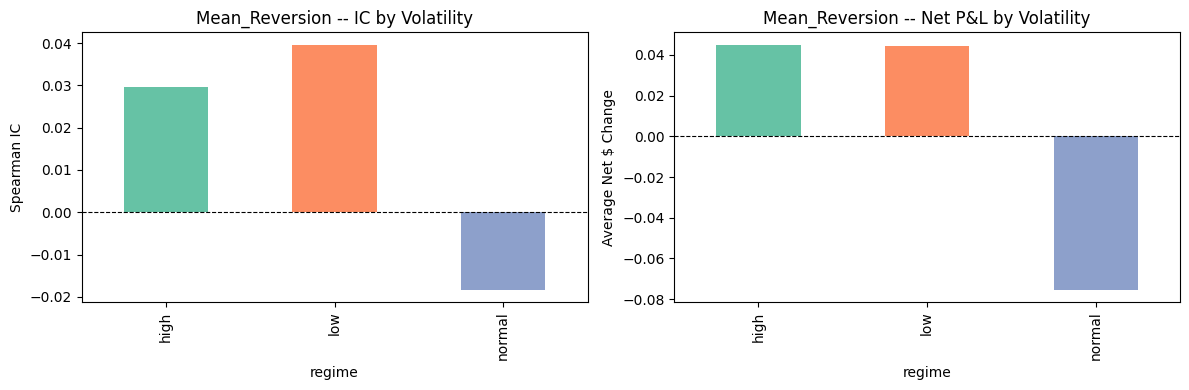

In [21]:
backtest_df['vol_regime'] = classify_vol_regime(marks['price_chg']).reindex(backtest_df.index)

vol_regime_summaries = {}
for signal in signals_df.columns:
    summary_df = summarise_regime(
        backtest_df[signal],
        backtest_df[f'terminal_change_{HORIZON_DAYS}d'],
        backtest_df[f'{signal}_net_pnl'],
        backtest_df['vol_regime'],
    )
    vol_regime_summaries[signal] = summary_df
    plot_signal_regime_summary(summary_df, signal_name=signal, regime_name='Volatility')

In [22]:
for signal, summary_df in vol_regime_summaries.items():
    print('\n' + '='*len(signal))
    print(signal)
    print('='*len(signal))
    display(summary_df.round(3))



=====
carry
=====


,n_obs,spearman_ic,pearson_ic,ic_t_stat,avg_net_pnl,hit_rate,sharpe
regime,,,,,,,
high,433,-0.009,-0.009,-0.220,0.032,0.499,0.233
low,428,-0.041,-0.008,-0.913,0.001,0.491,0.010
normal,863,0.012,-0.006,0.410,0.049,0.516,0.498



=====
trend
=====


,n_obs,spearman_ic,pearson_ic,ic_t_stat,avg_net_pnl,hit_rate,sharpe
regime,,,,,,,
high,433,-0.001,-0.010,-0.030,-0.022,0.506,-0.164
low,428,-0.065,-0.069,-1.497,-0.048,0.465,-0.597
normal,863,0.014,-0.007,0.441,-0.007,0.499,-0.070



mean_reversion


,n_obs,spearman_ic,pearson_ic,ic_t_stat,avg_net_pnl,hit_rate,sharpe
regime,,,,,,,
high,433,0.030,0.021,0.720,0.045,0.501,0.333
low,428,0.040,0.032,0.886,0.045,0.516,0.559
normal,863,-0.018,-0.016,-0.495,-0.075,0.461,-0.765


Conditioning on realised volatility, the split is cleaner, but still signal-specific rather than broadly supportive.

Carry is economically best in normal volatility, while both high- and low-volatility regimes are weaker. Since ICs remain close to zero in all three buckets and t-stats are low, I would not read this as stronger predictive strength, especially with the low t-stats. Though, given the idea behind carry, it does seem perfectly logical to get this results. With the absence of stochasticity, we expect deferred futures to roll up in backwardation and roll down in contango. With added noise, the performance would be less "predictable".

Trend is roughly flat in high and normal volatility, but clearly poor in low volatility. Mean reversion shows the opposite pattern, doing best in low volatility and losing money in normal volatility.

So this section does not support a simple statement that higher volatility is uniformly good or bad. Instead, it suggests that carry prefers calmer but still active markets, trend is unreliable in quiet markets, and mean reversion benefits most when realised volatility is subdued.

### 5.5.3 Across Pre/Post Covid Regimes

I treat the Covid split as a stress-period robustness check rather than the main regime framework. It is still useful to know whether the signal only works because of one unusual sub-period.


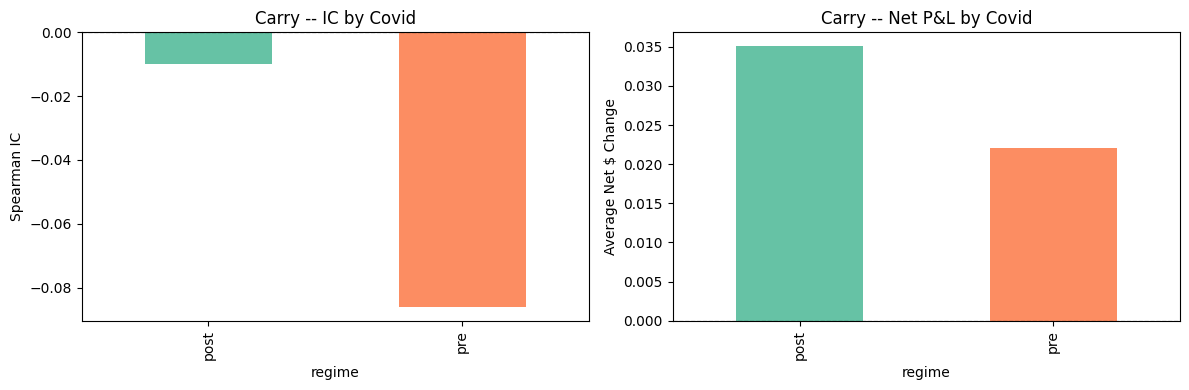

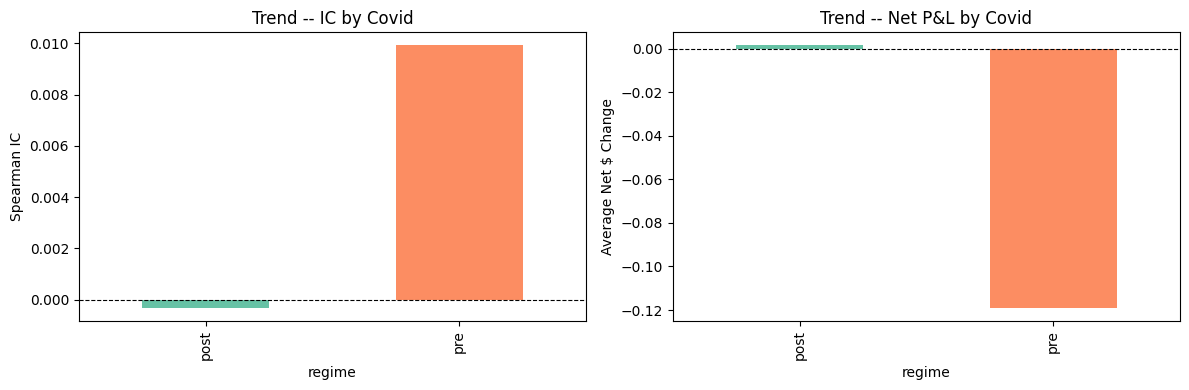

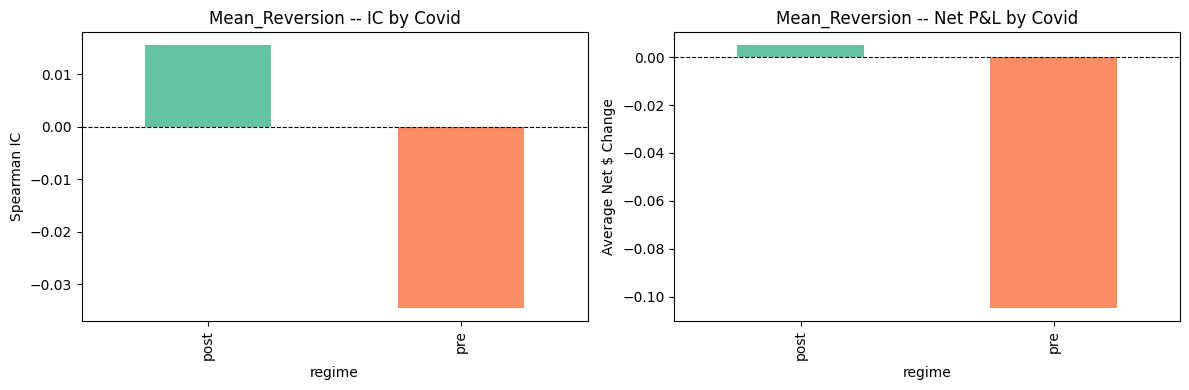

In [23]:
covid_regime_summaries = {}
for signal in signals_df.columns:
    summary_df = summarise_regime(
        backtest_df[signal],
        backtest_df[f'terminal_change_{HORIZON_DAYS}d'],
        backtest_df[f'{signal}_net_pnl'],
        backtest_df['pre_post_covid'],
    )
    covid_regime_summaries[signal] = summary_df
    plot_signal_regime_summary(summary_df, signal_name=signal, regime_name='Covid')


Conditioning on the pre/post-Covid split, I would treat this mostly as a robustness check rather than a primary regime framework. The sample imbalance is large, so I would not place much weight on small pre-Covid differences.

Carry monetises modestly in both periods, but IC is more negative pre-Covid and only slightly negative post-Covid, so this still does not support the original monotonic signal hypothesis. With weak IC and weak t-stats, I would not treat the observed P&L as especially reliable either.

Trend is close to flat post-Covid but materially worse pre-Covid, where the realised P&L is clearly negative. Mean reversion also looks poor pre-Covid and only mildly positive post-Covid. Overall, this split is less informative than term structure or realised volatility.

### 5.5.4 Commentary on IC by Regimes

Across all three regime cuts, the main conclusion does not change: ICs remain small and t-stats are weak, so I would not treat these as statistically convincing signals. Regime conditioning is therefore more useful here as a diagnostic than as evidence of predictive strength.

Term structure is the most informative split. Backwardation is the least bad environment for carry and trend, while contango is clearly poor for trend. Mean reversion behaves differently from the other two and holds up somewhat better in contango.

Volatility gives a different kind of separation. Carry works best when volatility is normal, which is economically plausible, but the ICs remain too weak to call this strong evidence. Trend remains weak, especially in low volatility, while mean reversion appears to do best when volatility is subdued.

Overall, regime analysis helps explain signal behaviour, but not enough to claim robust predictive power, at least not in this notebook.

# 6. Backtest Results

For simplicity, we'll just assume that we go long when the signal is positive and short when it is negative. This is an extreme simplification, but there are too many alternatives to carrying this out to contain in this notebook. These will be covered in potential areas of improvements in section 7 below.

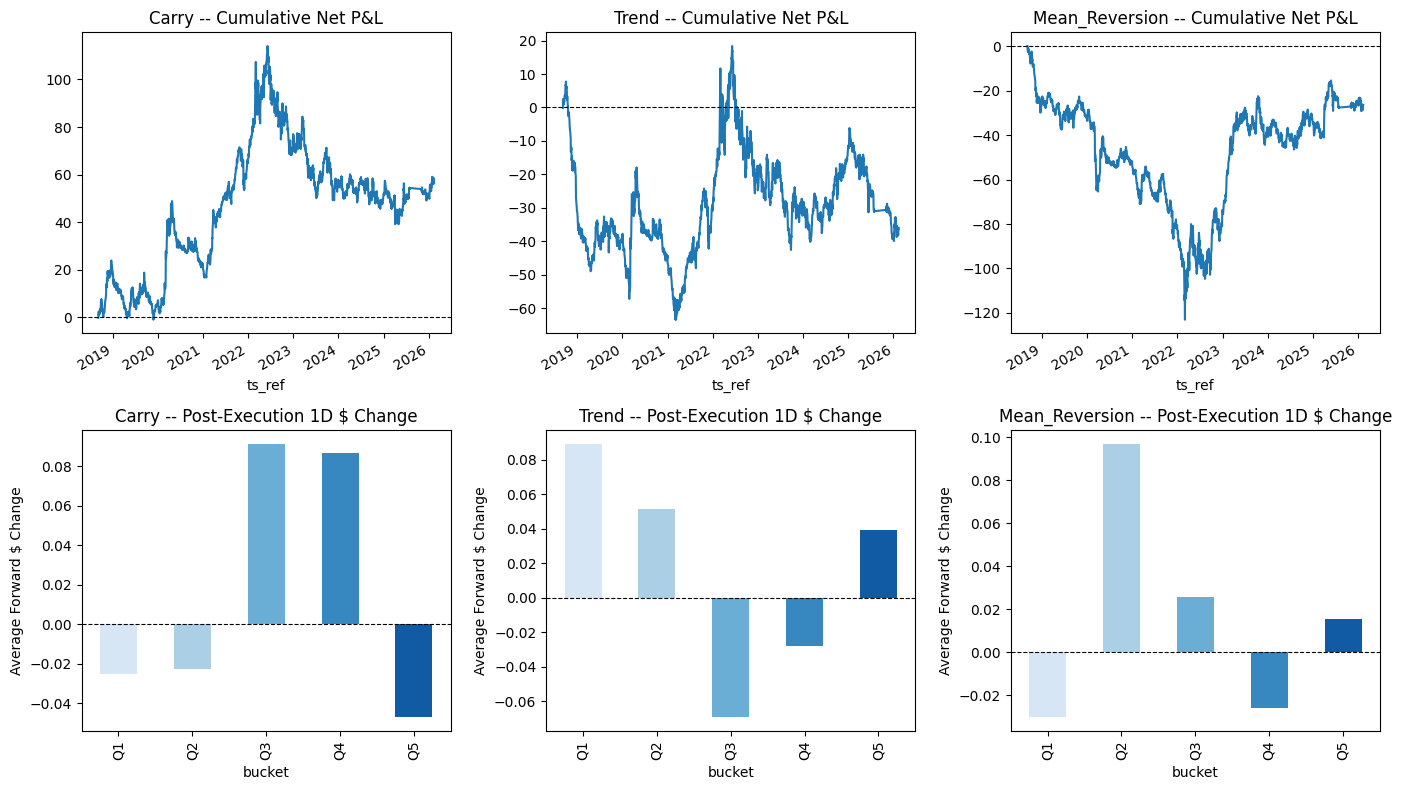

,mean_daily_net_pnl,annualised_net_pnl,sharpe,sortino,hit_rate,avg_position_turnover,max_drawdown,top_minus_bottom_bucket_spread
signal,,,,,,,,
carry,0.033,8.235,0.311,0.444,0.505,0.065,-74.89,-0.022
trend,-0.021,-5.252,-0.198,-0.276,0.492,0.071,-71.14,-0.050
mean_reversion,-0.015,-3.863,-0.146,-0.203,0.485,0.119,-123.20,0.046


,peak_date,trough_date,drawdown
0,2022-06-06,2025-05-01,-74.89
1,2022-06-06,2025-04-04,-74.87
2,2022-06-06,2025-04-08,-74.34
3,2022-06-06,2025-04-28,-74.02
4,2022-06-06,2025-05-05,-73.94


,peak_date,trough_date,drawdown
0,2018-10-01,2021-03-09,-71.14
1,2018-10-01,2021-03-03,-71.06
2,2018-10-01,2021-03-10,-70.78
3,2018-10-01,2021-03-11,-70.58
4,2018-10-01,2021-03-04,-70.07


,peak_date,trough_date,drawdown
0,2018-09-06,2022-03-03,-123.20
1,2018-09-06,2022-03-02,-119.51
2,2018-09-06,2022-02-28,-114.46
3,2018-09-06,2022-03-09,-113.70
4,2018-09-06,2022-03-04,-112.45


In [24]:
metrics = []
top_drawdowns = {}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
for i, signal in enumerate(signals_df.columns):
    signal_net_pnl = backtest_df[f'{signal}_net_pnl'].dropna()
    bucket_table, top_minus_bottom = compute_bucket_stats(
        backtest_df[signal],
        backtest_df[f'terminal_change_{HORIZON_DAYS}d'],
        n_buckets=5,
    )
    drawdown_stats = compute_drawdown_stats(signal_net_pnl)
    top_drawdowns[signal] = compute_top_drawdowns(signal_net_pnl, top_n=5)

    metrics.append({
        'signal': signal,
        'mean_daily_net_pnl': signal_net_pnl.mean(),
        'annualised_net_pnl': signal_net_pnl.mean() * PERIODS_PER_YEAR,
        'sharpe': compute_sharpe_raw(signal_net_pnl, periods_per_year=PERIODS_PER_YEAR),
        'sortino': compute_sortino_raw(signal_net_pnl, periods_per_year=PERIODS_PER_YEAR),
        'hit_rate': (signal_net_pnl > 0).mean(),
        'avg_position_turnover': compute_position_turnover(backtest_df[signal]),
        'max_drawdown': drawdown_stats['max_drawdown'],
        'top_minus_bottom_bucket_spread': top_minus_bottom,
    })

    signal_net_pnl.cumsum().plot(ax=axes[0, i], title=f'{signal.title()} -- Cumulative Net P&L')
    axes[0, i].axhline(0, c='black', lw=0.8, ls='--')

    bucket_table['mean'].plot(kind='bar', ax=axes[1, i], color=sns.color_palette('Blues', n_colors=bucket_table.shape[0]))
    axes[1, i].set_title(f'{signal.title()} -- Post-Execution 1D $ Change')
    axes[1, i].set_ylabel('Average Forward $ Change')
    axes[1, i].axhline(0, c='black', lw=0.8, ls='--')

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(metrics).set_index('signal').round(3)
display(metrics_df)

for signal, drawdown_table in top_drawdowns.items():
    display(drawdown_table)


Standalone backtest results are fairly clear in this run. Carry is the only signal that is positive on its own, but even there the Sharpe is only 0.311. Trend and mean reversion are both negative, with mean reversion showing the largest turnover and by far the deepest drawdown.

## 6.1 Orthogonalisation of Signals

So far, all signals have been studied on a standalone basis. The next question I would naturally ask is what is the information contribution of each signal and how do I account for P&L attribution.

Here, we perform a sequential orthogonalisation of the signals as covered in Qian et al (2007). I keep the signal order as carry, trend, then mean reversion. Carry therefore acts as the anchor signal.

In [25]:
orth_signals_df, r_squared = orthogonalise_signals_full_sample_sequential(
    signals_df,
    normalise_window=60,
)
display(r_squared.to_frame().round(3))


,full_sample_r_squared
carry,NaN
trend,0.186
mean_reversion,0.077


### 6.1.1 P&L Contribution per Signal

In [26]:
orth_comparison = []
for signal in signals_df.columns:
    raw_stats = compute_predictive_corr_stats(
        backtest_df[signal],
        backtest_df[f'terminal_change_{HORIZON_DAYS}d'],
        method='spearman',
    )
    orth_stats = compute_predictive_corr_stats(
        orth_signals_df[signal].reindex(backtest_df.index),
        backtest_df[f'terminal_change_{HORIZON_DAYS}d'],
        method='spearman',
    )

    orth_comparison.append({
        'signal': signal,
        'raw_ic': raw_stats['corr'],
        'orth_ic': orth_stats['corr'],
        'ic_retention': orth_stats['corr'] / raw_stats['corr'] if pd.notna(raw_stats['corr']) and raw_stats['corr'] != 0 else np.nan,
        'raw_t_stat': raw_stats['t_stat'],
        'orth_t_stat': orth_stats['t_stat'],
        'r_squared': r_squared[signal],
    })

orth_comparison_df = pd.DataFrame(orth_comparison).set_index('signal').round(3)
display(orth_comparison_df)


,raw_ic,orth_ic,ic_retention,raw_t_stat,orth_t_stat,r_squared
signal,,,,,,
carry,-0.005,-0.007,1.617,-0.221,-0.334,NaN
trend,-0.005,0.004,-0.750,-0.236,0.179,0.186
mean_reversion,0.005,0.027,5.451,0.201,1.079,0.077


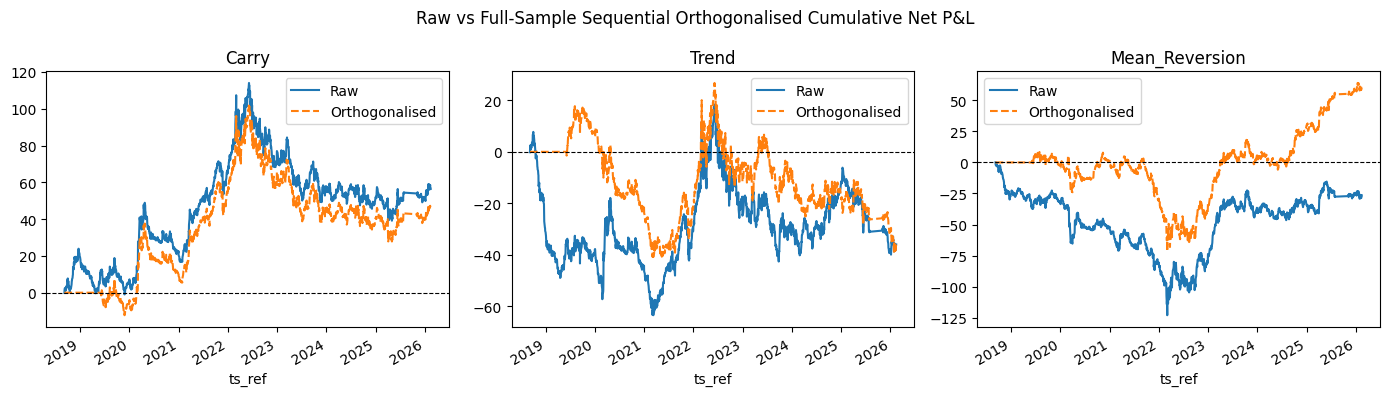

In [27]:
fig, axes = plt.subplots(ncols=3, figsize=(14, 4))

for i, signal in enumerate(signals_df.columns):
    raw_pnl = backtest_df[f'{signal}_net_pnl'].dropna()
    orth_pnl = compute_position_pnl(
        orth_signals_df[signal].reindex(backtest_df.index),
        backtest_df[f'terminal_change_{HORIZON_DAYS}d'],
        one_way_cost=ONE_WAY_COST_PER_CONTRACT,
    ).dropna()

    raw_pnl.cumsum().plot(ax=axes[i], label='Raw', lw=1.5)
    orth_pnl.cumsum().plot(ax=axes[i], label='Orthogonalised', lw=1.5, ls='--')
    axes[i].set_title(f'{signal.title()}')
    axes[i].axhline(0, c='black', lw=0.8, ls='--')
    axes[i].legend()

plt.suptitle('Raw vs Full-Sample Sequential Orthogonalised Cumulative Net P&L')
plt.tight_layout()
plt.show()


In [28]:
contribution_rows = []
for signal in signals_df.columns:
    raw_pnl = backtest_df[f'{signal}_net_pnl'].dropna()
    orth_pnl = compute_position_pnl(
        orth_signals_df[signal].reindex(backtest_df.index),
        backtest_df[f'terminal_change_{HORIZON_DAYS}d'],
        one_way_cost=ONE_WAY_COST_PER_CONTRACT,
    ).dropna()

    contribution_rows.append({
        'signal': signal,
        'raw_sharpe': compute_sharpe_raw(raw_pnl, periods_per_year=PERIODS_PER_YEAR),
        'orth_sharpe': compute_sharpe_raw(orth_pnl, periods_per_year=PERIODS_PER_YEAR),
        'raw_hit_rate': (raw_pnl > 0).mean(),
        'orth_hit_rate': (orth_pnl > 0).mean(),
        'full_sample_r_squared': r_squared[signal],
        'ic_retention': orth_comparison_df.loc[signal, 'ic_retention'],
    })

contribution_df = pd.DataFrame(contribution_rows).set_index('signal').round(3)
display(contribution_df)


,raw_sharpe,orth_sharpe,raw_hit_rate,orth_hit_rate,full_sample_r_squared,ic_retention
signal,,,,,,
carry,0.311,0.256,0.505,0.454,NaN,1.617
trend,-0.198,-0.205,0.492,0.447,0.186,-0.750
mean_reversion,-0.146,0.345,0.485,0.449,0.077,5.451


Under this sequential orthogonalisation, only mean reversion appears to retain a somewhat cleaner residual component. Being the anchor signal, carry is largely unchanged, while trend deteriorates.

Mean reversion improves visibly. Its orthogonal IC increases relative to the raw signal, and orthogonal Sharpe turns positive, while its full-sample $R^2$ is also the lowest of the three. That is at least consistent with mean reversion sharing less common variation with carry and trend than they share with one another.

Even so, I would keep the interpretation restrained. The orthogonal t-stats remain weak, and the overall signal remains far from compelling.

# 7. Areas of Improvements

1) Single instrument research that may be too narrowly scoped and potentially do not generalise well to other instruments

2) As of yet, roll costs are not taken into consideration. Though, in my opinion, costs could be argued to be secondary as when we construct a portfolio, we could pool multiple weak signals together and tune the optimisation engine to take a position or fulfill the turnover only if the expected returns exceeds the cost amortised.

3) Hold-out set should have been used, where we train and validate on a training and validation set. Thereafter, when we have completed our analysis we could run a simulation on the test set to study out-of-sample / walk-forward performance

4) Multiple testing adjustments. Since these signals have been widely studied and we implemented a parameter sweep, we should adjust our analysis to account for multiple testing.

5) Backtesting could be done on a volatility-scaled basis or entry and exit conditions could be implemented based on some discrete levels, e.g. 1/2/3 z-scores. Currently, what we do is trade based on signal signs.

6) Backtests is not cost-aware, in the sense that it does not prevent trading even when expected returns do not cover cost.